In [33]:
#Parham Porkhial student no: 97543278
import numpy as np           # Importing NumPy library and aliasing it as 'np'
import tensorflow as tf       # Importing TensorFlow library and aliasing it as 'tf'
import matplotlib.pyplot as plt  # Importing Matplotlib library and aliasing it as 'plt'
import pandas as pd          # Importing Pandas library and aliasing it as 'pd'


In [34]:
import scipy.io  # Importing the scipy.io module

mat = scipy.io.loadmat('/content/Mackey.mat')  # Loading a MATLAB file using scipy.io.loadmat()


In [35]:
# Creating a NumPy array 'x' containing values from 1 to 500
x = np.arange(1, 501)  # Generates a sequence of numbers from 1 to 500 (inclusive start, exclusive stop)


In [36]:
y = mat['MackeyGlass']  # Accessing the variable 'MackeyGlass' from the loaded MATLAB file as our desired(y)


In [37]:
np.shape(y)

(500, 1)

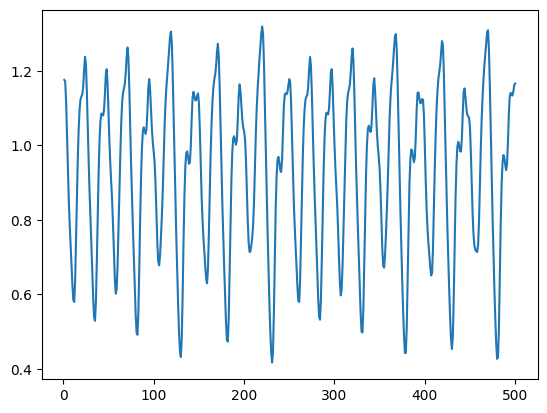

In [38]:
plt.plot(x,y) # making the plotof x and y, notice the x is the horizontal axis and y is the vertical axis of plot

In [39]:

#making our input variable which in order to improve the performance of the ANN and using least epochs we use the input which is an array of 500
# data and each data is an vertical array which contain the y of its counterpart and at least the nine y which were previous to the y that is
# counterpart of the input
# P.S= y[10] is the counterpart of input[10]
# since the len of x and y are 500 so the first dimension of input matrix is 500
input = np.zeros([500, 10])
input[0]= y[0], 0, 0, 0, 0, 0, 0, 0, 0, 0
input[1]= y[1],y[0], 0, 0, 0, 0, 0, 0, 0, 0
input[2]= y[2],y[1],y[0], 0, 0, 0, 0, 0, 0, 0
input[3]= y[3],y[2],y[1],y[0], 0, 0, 0, 0, 0, 0
input[4] = y[4],y[3],y[2],y[1],y[0], 0, 0, 0, 0, 0
input[5] = y[5],y[4],y[3], y[2],y[1] ,y[0], 0, 0, 0, 0
input[6]= y[6],y[5],y[4],y[3],y[2],y[1],y[0], 0, 0, 0
input[7]= y[7],y[6],y[5],y[4],y[3],y[2],y[1],y[0], 0, 0
input[8]= y[8],y[7],y[6],y[5],y[4],y[3], y[2],y[1],y[0], 0
input[9]= y[9],y[8],y[7],y[6],y[5],y[4],y[3],y[2],y[1],y[0]
i = 10
while i<500:
  input[i]=y[i],y[i-1],y[i-2],y[i-3],y[i-4],y[i-5],y[i-6],y[i-7],y[i-8],y[i-9]
  i+=1

<ipython-input-39-96238c569176>:7: DeprecationWarning: setting an array element with a sequence. This was supported in some cases where the elements are arrays with a single element. For example `np.array([1, np.array([2])], dtype=int)`. In the future this will raise the same ValueError as `np.array([1, [2]], dtype=int)`.
  input[0]= y[0], 0, 0, 0, 0, 0, 0, 0, 0, 0
<ipython-input-39-96238c569176>:8: DeprecationWarning: setting an array element with a sequence. This was supported in some cases where the elements are arrays with a single element. For example `np.array([1, np.array([2])], dtype=int)`. In the future this will raise the same ValueError as `np.array([1, [2]], dtype=int)`.
  input[1]= y[1],y[0], 0, 0, 0, 0, 0, 0, 0, 0
<ipython-input-39-96238c569176>:9: DeprecationWarning: setting an array element with a sequence. This was supported in some cases where the elements are arrays with a single element. For example `np.array([1, np.array([2])], dtype=int)`. In the future this will 

In [40]:
ann = tf.keras.models.Sequential()
#making our ann with tensor flow library. however, we should consider that the sequential function just make an empty ann and we should add
#our hidden layer with add function like below
ann.add(tf.keras.layers.Dense(units=40,activation='sigmoid')) #make the first hidden layer with 40 neurons and the activation function of sigmoid
ann.add(tf.keras.layers.Dense(units=12,activation='sigmoid')) ##make the second hidden layer with 12 neurons and the activation function of sigmoid
ann.add(tf.keras.layers.Dense(units=1)) #make the output layer which contains our desired(which is an specific y_pred)
ann.compile(loss='mean_squared_error' ,optimizer='adam',metrics=['mean_squared_error'])
#merge all the layer and make the ANN and define the way we cosider our loss, optimizer and metrices(اینکه چه نوع تابع خطا و بهینه سازی استفاده کنیم تجربی است همانند تعداد نورون ها)

In [41]:
ann.fit(input, y, epochs = 200, batch_size = 16)
# specify the inputs for ANN and train the network for 200 times and divide the data in the pack of 16 to reduced the memory consumption of code(اگر یکجا کل داده رو بدهیم به شبکه ممکنه حافظه پر شود)


Epoch 1/200
32/32 [==============================] - 1s 3ms/step - loss: 0.5056 - mean_squared_error: 0.5056
Epoch 2/200
32/32 [==============================] - 0s 3ms/step - loss: 0.0595 - mean_squared_error: 0.0595
Epoch 3/200
32/32 [==============================] - 0s 3ms/step - loss: 0.0486 - mean_squared_error: 0.0486
Epoch 4/200
32/32 [==============================] - 0s 3ms/step - loss: 0.0475 - mean_squared_error: 0.0475
Epoch 5/200
32/32 [==============================] - 0s 4ms/step - loss: 0.0467 - mean_squared_error: 0.0467
Epoch 6/200
32/32 [==============================] - 0s 5ms/step - loss: 0.0458 - mean_squared_error: 0.0458
Epoch 7/200
32/32 [==============================] - 0s 6ms/step - loss: 0.0450 - mean_squared_error: 0.0450
Epoch 8/200
32/32 [==============================] - 0s 6ms/step - loss: 0.0436 - mean_squared_error: 0.0436
Epoch 9/200
32/32 [==============================] - 0s 6ms/step - loss: 0.0423 - mean_squared_error: 0.0423
Epoch 10/200
32/32 

In [42]:
#As you can see the result have the error on the power of -4, so the ANN is reliable
y_pred = ann.predict(input)
# put the prediction of input in y_pred in order to compare the result of ANN and the actual value we have(y)


16/16 [==============================] - 0s 2ms/step


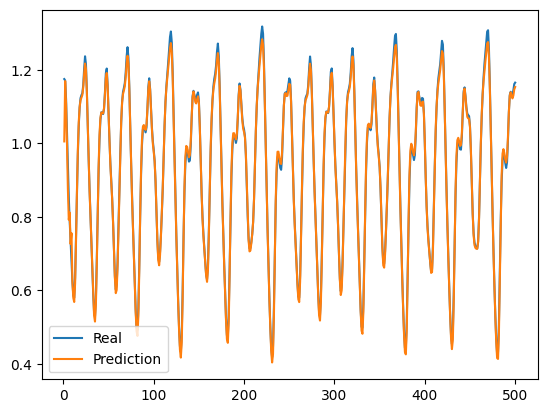

In [43]:
plt.plot(x,y, label ='Real')
plt.plot(x,y_pred, label='Prediction')
plt.legend()
# Comparing the Real values and the prediction Values which are really close to each other

## Using the X and Y of the data directly
## and increasing the number of training(epochs)
## to compare two different approach with each other

In [44]:
ann2 = tf.keras.models.Sequential()
#making our ann2 with tensor flow library. however, we should consider that the sequential function just make an empty ann and we should add
#our hidden layer with add function like below
ann2.add(tf.keras.layers.Dense(units=40,activation='sigmoid')) #make the first hidden layer with 40 neurons and the activation function of sigmoid
ann2.add(tf.keras.layers.Dense(units=12,activation='sigmoid')) ##make the second hidden layer with 12 neurons and the activation function of sigmoid
ann2.add(tf.keras.layers.Dense(units=1)) #make the output layer which contains our desired(which is an specific y_pred)
ann2.compile(loss='mean_squared_error' ,optimizer='adam',metrics=['mean_squared_error'])
#merge all the layer and make the ANN and define the way we cosider our loss, optimizer and metrices(اینکه چه نوع تابع خطا و بهینه سازی استفاده کنیم تجربی است همانند تعداد نورون ها)

In [45]:
new_x = x.reshape(-1, 1) #changing the form of x from1D dimensional matrix to 2D
np.shape(new_x)

(500, 1)

In [46]:
ann2.fit(new_x, y, epochs = 400, batch_size = 16)
# specify the inputs for ANN and train the network for 400 times and divide the data in the pack of 16 to reduced the memory consumption of code(اگر یکجا کل داده رو بدهیم به شبکه ممکنه حافظه پر شود)


Epoch 1/400
32/32 [==============================] - 1s 3ms/step - loss: 2.3704 - mean_squared_error: 2.3704
Epoch 2/400
32/32 [==============================] - 0s 3ms/step - loss: 0.8263 - mean_squared_error: 0.8263
Epoch 3/400
32/32 [==============================] - 0s 3ms/step - loss: 0.2517 - mean_squared_error: 0.2517
Epoch 4/400
32/32 [==============================] - 0s 3ms/step - loss: 0.0719 - mean_squared_error: 0.0719
Epoch 5/400
32/32 [==============================] - 0s 3ms/step - loss: 0.0513 - mean_squared_error: 0.0513
Epoch 6/400
32/32 [==============================] - 0s 3ms/step - loss: 0.0516 - mean_squared_error: 0.0516
Epoch 7/400
32/32 [==============================] - 0s 3ms/step - loss: 0.0513 - mean_squared_error: 0.0513
Epoch 8/400
32/32 [==============================] - 0s 3ms/step - loss: 0.0512 - mean_squared_error: 0.0512
Epoch 9/400
32/32 [==============================] - 0s 3ms/step - loss: 0.0513 - mean_squared_error: 0.0513
Epoch 10/400
32/32 

In [51]:
#As you can see the result have the error of .05 after 400 epochs , so the ANN2 is  not reliable
y_pred2 = ann2.predict(new_x)
# put the prediction of input in y_pred in order to compare the result of ANN and the actual value we have(y)

16/16 [==============================] - 0s 2ms/step


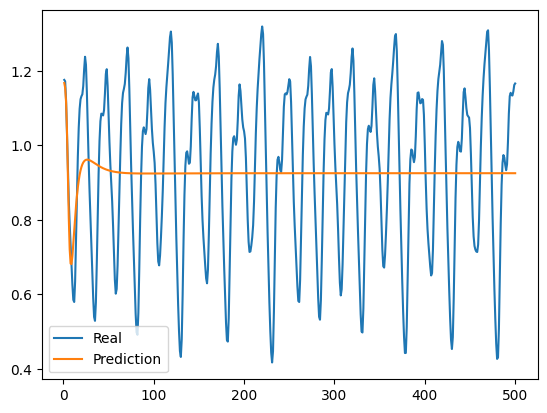

In [52]:
plt.plot(x,y, label ='Real')
plt.plot(new_x,y_pred2, label='Prediction')
plt.legend()
# Comparing the Real values and the prediction Values which are not really close to each other and the prediction is really messed up